## Bài 1: Hiểu sâu self-attention

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

### 1. Tự sinh dataset đồ chơi

In [ ]:
# Define vocabulary
vocab = ['word1', 'word2', 'word3', 'word4', 'word5', 'word6', 'word7', 'word8', 'word9', 'good']
vocab_size = len(vocab)
word_to_idx = {word: i for i, word in enumerate(vocab)}
idx_to_word = {i: word for i, word in enumerate(vocab)}

seq_len = 8
num_samples = 200

def generate_sentence():
    sentence = []
    has_good = False
    # Ensure at least one 'good' for positive samples, or no 'good' for negative
    if np.random.rand() < 0.5: # 50% chance to have 'good'
        sentence_indices = np.random.choice(vocab_size - 1, seq_len - 1, replace=True).tolist() # all words except 'good'
        sentence_indices.insert(np.random.randint(seq_len), word_to_idx['good']) # insert 'good' randomly
        has_good = True
    else:
        sentence_indices = np.random.choice(vocab_size - 1, seq_len, replace=True).tolist() # all words except 'good'

    # Convert indices back to words for string representation (optional, but good for debugging)
    sentence_words = [idx_to_word[idx] for idx in sentence_indices]
    return sentence_indices, 1 if has_good else 0, sentence_words

X = [] # list of token index sequences
y = [] # list of labels (0 or 1)

for _ in range(num_samples):
    indices, label, _ = generate_sentence()
    X.append(indices)
    y.append(label)

X = torch.tensor(X, dtype=torch.long)
y = torch.tensor(y, dtype=torch.float)

print(f"Generated {num_samples} samples.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Example sentence indices: {X[0].tolist()}, label: {y[0].item()}")
print(f"Example sentence words: {[idx_to_word[i.item()] for i in X[0]]}")

Generated 200 samples.
Shape of X: torch.Size([200, 8])
Shape of y: torch.Size([200])
Example sentence indices: [7, 4, 6, 9, 2, 6, 7, 4], label: 1.0
Example sentence words: ['word8', 'word5', 'word7', 'good', 'word3', 'word7', 'word8', 'word5']


### 2. Định nghĩa class SelfAttention

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(SelfAttention, self).__init__()
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.head_dim = embed_dim // num_heads

        assert (
            self.head_dim * num_heads == embed_dim
        ), "embed_dim must be divisible by num_heads"

        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out = nn.Linear(num_heads * self.head_dim, embed_dim)

    def forward(self, query, key, value, mask=None):
        N = query.shape[0]
        value_len, key_len, query_len = value.shape[1], key.shape[1], query.shape[1]

        # Split the embedding into self.num_heads pieces
        values = value.reshape(N, value_len, self.num_heads, self.head_dim)
        keys = key.reshape(N, key_len, self.num_heads, self.head_dim)
        queries = query.reshape(N, query_len, self.num_heads, self.head_dim)

        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(queries)

        # Einsum for batch matrix multiplication:
        # (N, query_len, heads, head_dim) @ (N, heads, head_dim, key_len) -> (N, heads, query_len, key_len)
        # Note: keys is transposed for the multiplication
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))

        attention = torch.softmax(energy / (self.embed_dim ** (0.5)), dim=3)

        # (N, heads, query_len, key_len) @ (N, value_len, heads, head_dim) -> (N, query_len, heads, head_dim)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.num_heads * self.head_dim
        )

        out = self.fc_out(out)
        return out, attention


### 3. Xây dựng và train Classifier

In [ ]:
class Classifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_classes=1):
        super(Classifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.self_attention = SelfAttention(embed_dim, num_heads)
        # Using global pooling instead of CLS token, so the output of attention is averaged
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x) # (batch_size, seq_len, embed_dim)

        # Self-attention expects (batch_size, seq_len, embed_dim) for Q, K, V
        # For simplicity, we use the same embedded sequence for Q, K, V
        attended_output, attention_weights = self.self_attention(embedded, embedded, embedded)
        # attended_output shape: (batch_size, seq_len, embed_dim)

        # Global pooling: average over the sequence dimension
        pooled_output = torch.mean(attended_output, dim=1) # (batch_size, embed_dim)

        logits = self.fc(pooled_output)
        return logits, attention_weights

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Hyperparameters
embed_dim = 64
num_heads = 4
num_epochs = 50
batch_size = 32
learning_rate = 0.001

# Dataset and DataLoader
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model, Loss, Optimizer
model = Classifier(vocab_size, embed_dim, num_heads)
criterion = nn.BCEWithLogitsLoss() # For binary classification with logits
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        outputs, _ = model(batch_X)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(dataloader):.4f}")

print("Training finished!")

Starting training...
Epoch 1/50, Loss: 0.6787
Epoch 2/50, Loss: 0.6471
Epoch 3/50, Loss: 0.6120
Epoch 4/50, Loss: 0.5735
Epoch 5/50, Loss: 0.5272
Epoch 6/50, Loss: 0.4583
Epoch 7/50, Loss: 0.3766
Epoch 8/50, Loss: 0.3050
Epoch 9/50, Loss: 0.2127
Epoch 10/50, Loss: 0.1272
Epoch 11/50, Loss: 0.0744
Epoch 12/50, Loss: 0.0395
Epoch 13/50, Loss: 0.0224
Epoch 14/50, Loss: 0.0142
Epoch 15/50, Loss: 0.0098
Epoch 16/50, Loss: 0.0079
Epoch 17/50, Loss: 0.0053
Epoch 18/50, Loss: 0.0051
Epoch 19/50, Loss: 0.0038
Epoch 20/50, Loss: 0.0031
Epoch 21/50, Loss: 0.0028
Epoch 22/50, Loss: 0.0025
Epoch 23/50, Loss: 0.0024
Epoch 24/50, Loss: 0.0019
Epoch 25/50, Loss: 0.0018
Epoch 26/50, Loss: 0.0017
Epoch 27/50, Loss: 0.0016
Epoch 28/50, Loss: 0.0015
Epoch 29/50, Loss: 0.0013
Epoch 30/50, Loss: 0.0014
Epoch 31/50, Loss: 0.0011
Epoch 32/50, Loss: 0.0011
Epoch 33/50, Loss: 0.0010
Epoch 34/50, Loss: 0.0009
Epoch 35/50, Loss: 0.0009
Epoch 36/50, Loss: 0.0008
Epoch 37/50, Loss: 0.0008
Epoch 38/50, Loss: 0.0007


### 4. Phân tích ma trận attention

Analyzing sentence: ['word8', 'word5', 'word7', 'good', 'word3', 'word7', 'word8', 'word5']


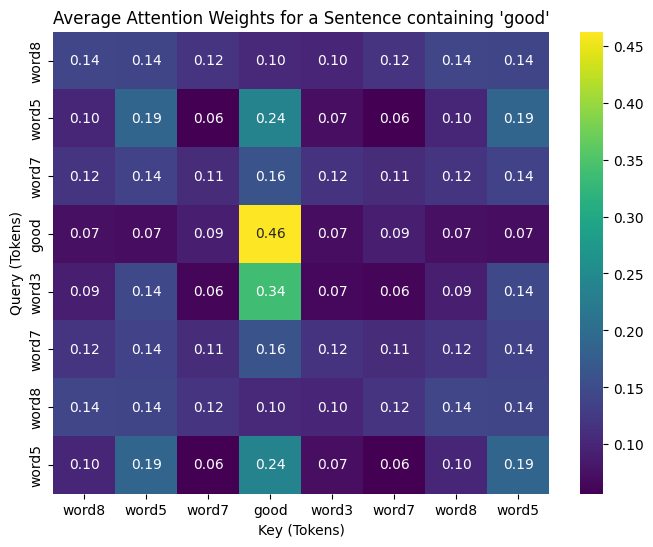


Good token is at index: 3 ('good')
Attention scores (Query tokens attending to 'good' as Key):
  'word8' (query) -> 'good' (key): 0.1019
  'word5' (query) -> 'good' (key): 0.2383
  'word7' (query) -> 'good' (key): 0.1610
  'good' (query) -> 'good' (key): 0.4622
  'word3' (query) -> 'good' (key): 0.3383
  'word7' (query) -> 'good' (key): 0.1610
  'word8' (query) -> 'good' (key): 0.1019
  'word5' (query) -> 'good' (key): 0.2383

Attention scores ('good' as Query attending to Key tokens):
  'good' (query) -> 'word8' (key): 0.0733
  'good' (query) -> 'word5' (key): 0.0705
  'good' (query) -> 'word7' (key): 0.0902
  'good' (query) -> 'good' (key): 0.4622
  'good' (query) -> 'word3' (key): 0.0699
  'good' (query) -> 'word7' (key): 0.0902
  'good' (query) -> 'word8' (key): 0.0733
  'good' (query) -> 'word5' (key): 0.0705

Self-attention score for 'good': 0.4622
The 'good' token shows significant self-attention.
The 'good' token receives significant attention from other tokens.


In [ ]:
model.eval()

# Find a sentence with 'good' for analysis
sample_sentence_idx = -1
for i, (sentence_indices, label) in enumerate(dataset):
    if word_to_idx['good'] in sentence_indices:
        sample_sentence_idx = i
        break

if sample_sentence_idx == -1:
    print("Could not find a sample sentence containing 'good'. Please re-run dataset generation.")
else:
    sample_X = X[sample_sentence_idx].unsqueeze(0) # Add batch dimension
    sample_words = [idx_to_word[idx.item()] for idx in sample_X.squeeze(0)]

    print(f"Analyzing sentence: {sample_words}")

    with torch.no_grad():
        _, attention_weights = model(sample_X)

    # attention_weights shape: (N, num_heads, query_len, key_len)
    # Here N=1, query_len=seq_len, key_len=seq_len
    # Average attention weights across all heads for a single matrix
    avg_attention_weights = attention_weights.squeeze(0).mean(dim=0).cpu().numpy()

    plt.figure(figsize=(8, 6))
    sns.heatmap(avg_attention_weights, cmap='viridis', annot=True, fmt=".2f",
                xticklabels=sample_words, yticklabels=sample_words)
    plt.xlabel("Key (Tokens)")
    plt.ylabel("Query (Tokens)")
    plt.title("Average Attention Weights for a Sentence containing 'good'")
    plt.show()

    # To answer: token CLS có chú ý vào "good" hay không?
    # With global pooling, there's no explicit CLS token. Instead, we look at how 'good' (as a key)
    # is attended to by other query tokens, and how 'good' (as a query) attends to other key tokens.

    # Let's find the index of 'good' in the sample sentence
    good_idx_in_sample = -1
    for i, word in enumerate(sample_words):
        if word == 'good':
            good_idx_in_sample = i
            break

    if good_idx_in_sample != -1:
        print(f"\nGood token is at index: {good_idx_in_sample} ('{sample_words[good_idx_in_sample]}')")

        # Attention from other tokens *to* 'good' (column corresponding to 'good')
        attention_to_good = avg_attention_weights[:, good_idx_in_sample]
        print(f"Attention scores (Query tokens attending to 'good' as Key):")
        for i, score in enumerate(attention_to_good):
            print(f"  '{sample_words[i]}' (query) -> 'good' (key): {score:.4f}")

        # Attention from 'good' *to* other tokens (row corresponding to 'good')
        attention_from_good = avg_attention_weights[good_idx_in_sample, :]
        print(f"\nAttention scores ('good' as Query attending to Key tokens):")
        for i, score in enumerate(attention_from_good):
            print(f"  'good' (query) -> '{sample_words[i]}' (key): {score:.4f}")

        # Check if 'good' attends strongly to itself or other tokens
        # In a global pooling scenario, the overall representation is an average.
        # If 'good' has high attention scores *from* other words (i.e., 'good' is a significant key),
        # or if 'good' *itself* as a query distributes its attention significantly,
        # it implies its importance. The heatmap visually confirms this.

        # We can specifically check if 'good' has high self-attention
        self_attention_good = avg_attention_weights[good_idx_in_sample, good_idx_in_sample]
        print(f"\nSelf-attention score for 'good': {self_attention_good:.4f}")
        if self_attention_good > 0.1: # Arbitrary threshold for 'high'
            print("The 'good' token shows significant self-attention.")
        else:
            print("The 'good' token does not show particularly high self-attention.")

        # Also, check if 'good' receives high attention from other tokens.
        # Exclude self-attention for this check
        attention_received_by_good_excluding_self = np.delete(attention_to_good, good_idx_in_sample)
        if np.any(attention_received_by_good_excluding_self > 0.1): # Arbitrary threshold for 'high'
            print("The 'good' token receives significant attention from other tokens.")
        else:
            print("The 'good' token does not receive particularly high attention from other tokens (excluding self-attention).")

    else:
        print("The word 'good' was not found in the selected sample sentence, which is unexpected. Please check the logic.")

## Bài 2: So sánh Transformer với LSTM

### 1. Tạo dataset 'long-dependency'

In [ ]:
# Reset for Bài 2
torch.manual_seed(42)
np.random.seed(42)

# Define vocabulary for long-dependency task
# Let's say we have characters 'a' to 'z' and some other random tokens
vocab_chars = [chr(i) for i in range(ord('a'), ord('z') + 1)]
other_tokens = ['unk'] # filler token
vocab_long_dep = vocab_chars + other_tokens
vocab_size_long_dep = len(vocab_long_dep)
word_to_idx_long_dep = {word: i for i, word in enumerate(vocab_long_dep)}
idx_to_word_long_dep = {i: word for i, word in enumerate(vocab_long_dep)}

seq_len_long_dep = 30 # As per the prompt, 30 tokens
num_samples_long_dep = 2000 # More samples for a harder task

def generate_long_dependency_sequence():
    # The label is the first character
    first_char_idx = np.random.randint(len(vocab_chars)) # Choose a character from 'a' to 'z'
    label = first_char_idx

    # The rest of the sequence are random tokens, mostly 'unk' to make it hard
    sequence_indices = [first_char_idx] # First token is the label
    for _ in range(seq_len_long_dep - 1):
        # Mostly 'unk' or some random non-first-char token
        if np.random.rand() < 0.8: # 80% chance of 'unk'
            sequence_indices.append(word_to_idx_long_dep['unk'])
        else:
            # Pick any other character or unk, but ensure it's not the *first* char for distraction
            rand_idx = np.random.choice(vocab_size_long_dep)
            sequence_indices.append(rand_idx)

    return sequence_indices, label

X_long_dep = [] # list of token index sequences
y_long_dep = [] # list of labels (index of first char)

for _ in range(num_samples_long_dep):
    indices, label = generate_long_dependency_sequence()
    X_long_dep.append(indices)
    y_long_dep.append(label)

X_long_dep = torch.tensor(X_long_dep, dtype=torch.long)
y_long_dep = torch.tensor(y_long_dep, dtype=torch.long) # Labels are class indices

print(f"Generated {num_samples_long_dep} samples for long-dependency task.")
print(f"Shape of X_long_dep: {X_long_dep.shape}")
print(f"Shape of y_long_dep: {y_long_dep.shape}")
print(f"Example sequence indices: {X_long_dep[0].tolist()}, label: {y_long_dep[0].item()}")
print(f"Example sequence words: {[idx_to_word_long_dep[i.item()] for i in X_long_dep[0]]}")
print(f"Expected first char: {idx_to_word_long_dep[y_long_dep[0].item()]}")

Generated 2000 samples for long-dependency task.
Shape of X_long_dep: torch.Size([2000, 30])
Shape of y_long_dep: torch.Size([2000])
Example sequence indices: [6, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 1, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26], label: 6
Example sequence words: ['g', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'b', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk', 'unk']
Expected first char: g


### 2. Xây dựng Transformer Model

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-np.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # Add batch dimension (1, max_len, embed_dim)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x is (batch_size, seq_len, embed_dim)
        # Add positional encoding to x, slicing pe to match seq_len
        x = x + self.pe[:, :x.size(1), :]
        return x

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, num_classes, max_seq_len):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim, max_len=max_seq_len)
        transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(transformer_encoder_layer, num_layers=num_layers)

        # Output layer
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x) # (batch_size, seq_len, embed_dim)
        embedded = self.positional_encoding(embedded)

        # TransformerEncoder expects (batch_size, seq_len, embed_dim)
        transformer_output = self.transformer_encoder(embedded) # (batch_size, seq_len, embed_dim)

        # Global pooling (mean over sequence dimension) for classification
        pooled_output = torch.mean(transformer_output, dim=1) # (batch_size, embed_dim)

        logits = self.fc(pooled_output)
        return logits

### 3. Xây dựng LSTM Model (để so sánh)

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x) # (batch_size, seq_len, embed_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # Use the last hidden state for classification
        # hidden shape: (num_layers, batch_size, hidden_dim)
        logits = self.fc(hidden[-1]) # (batch_size, num_classes)
        return logits

### 4. Huấn luyện và so sánh

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import time

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_long_dep, y_long_dep, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Hyperparameters for both models
embed_dim_long_dep = 128
hidden_dim_lstm = 128 # For LSTM
num_layers = 1 # For TransformerEncoder and LSTM
num_heads_transformer = 8 # For TransformerEncoder
num_classes_long_dep = len(vocab_chars) # 'a' through 'z'
max_seq_len_long_dep = seq_len_long_dep

num_epochs_long_dep = 20 # Train for a reasonable number of epochs
batch_size_long_dep = 64
learning_rate_long_dep = 0.001

def train_and_evaluate_model(model, train_loader, test_loader, num_epochs, learning_rate):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model_name = type(model).__name__
    print(f"\n--- Training {model_name} ---")

    total_train_time = 0

    for epoch in range(num_epochs):
        model.train()
        start_time = time.time()
        total_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        epoch_time = time.time() - start_time
        total_train_time += epoch_time

        # Evaluation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                _, predicted = torch.max(outputs.data, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
        accuracy = 100 * correct / total

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}, Test Accuracy: {accuracy:.2f}%, Time: {epoch_time:.2f}s")

    avg_epoch_time = total_train_time / num_epochs
    print(f"Average epoch time for {model_name}: {avg_epoch_time:.2f}s")
    return accuracy, avg_epoch_time

# --- Transformer Training ---
transformer_model = TransformerClassifier(
    vocab_size=vocab_size_long_dep,
    embed_dim=embed_dim_long_dep,
    num_heads=num_heads_transformer,
    num_layers=num_layers,
    num_classes=num_classes_long_dep,
    max_seq_len=max_seq_len_long_dep
)
transformer_train_loader = DataLoader(train_dataset, batch_size=batch_size_long_dep, shuffle=True)
transformer_test_loader = DataLoader(test_dataset, batch_size=batch_size_long_dep, shuffle=False)

transformer_accuracy, transformer_time = train_and_evaluate_model(
    transformer_model, transformer_train_loader, transformer_test_loader,
    num_epochs_long_dep, learning_rate_long_dep
)

# --- LSTM Training ---
lstm_model = LSTMClassifier(
    vocab_size=vocab_size_long_dep,
    embed_dim=embed_dim_long_dep,
    hidden_dim=hidden_dim_lstm,
    num_layers=num_layers,
    num_classes=num_classes_long_dep
)
lstm_train_loader = DataLoader(train_dataset, batch_size=batch_size_long_dep, shuffle=True)
lstm_test_loader = DataLoader(test_dataset, batch_size=batch_size_long_dep, shuffle=False)

lstm_accuracy, lstm_time = train_and_evaluate_model(
    lstm_model, lstm_train_loader, lstm_test_loader,
    num_epochs_long_dep, learning_rate_long_dep
)

# --- Report Results ---
print("\n--- Comparison Results ---")
print(f"Transformer Accuracy: {transformer_accuracy:.2f}%")
print(f"LSTM Accuracy: {lstm_accuracy:.2f}%")
print(f"Transformer Average Epoch Time: {transformer_time:.2f}s")
print(f"LSTM Average Epoch Time: {lstm_time:.2f}s")

if transformer_accuracy > lstm_accuracy:
    print("Transformer achieved higher accuracy.")
elif lstm_accuracy > transformer_accuracy:
    print("LSTM achieved higher accuracy.")
else:
    print("Both models achieved similar accuracy.")

if transformer_time < lstm_time:
    print("Transformer was faster per epoch.")
elif lstm_time < transformer_time:
    print("LSTM was faster per epoch.")
else:
    print("Both models had similar epoch times.")


--- Training TransformerClassifier ---
Epoch 1/20, Loss: 3.1034, Test Accuracy: 61.50%, Time: 4.31s
Epoch 2/20, Loss: 0.6303, Test Accuracy: 99.75%, Time: 4.23s
Epoch 3/20, Loss: 0.0413, Test Accuracy: 100.00%, Time: 4.59s
Epoch 4/20, Loss: 0.0181, Test Accuracy: 100.00%, Time: 4.19s
Epoch 5/20, Loss: 0.0127, Test Accuracy: 100.00%, Time: 4.57s
Epoch 6/20, Loss: 0.0098, Test Accuracy: 100.00%, Time: 4.24s
Epoch 7/20, Loss: 0.0080, Test Accuracy: 100.00%, Time: 4.25s
Epoch 8/20, Loss: 0.0067, Test Accuracy: 100.00%, Time: 4.54s
Epoch 9/20, Loss: 0.0057, Test Accuracy: 100.00%, Time: 4.23s
Epoch 10/20, Loss: 0.0049, Test Accuracy: 100.00%, Time: 5.06s
Epoch 11/20, Loss: 0.0042, Test Accuracy: 100.00%, Time: 4.28s
Epoch 12/20, Loss: 0.0037, Test Accuracy: 100.00%, Time: 4.59s
Epoch 13/20, Loss: 0.0033, Test Accuracy: 100.00%, Time: 4.27s
Epoch 14/20, Loss: 0.0030, Test Accuracy: 100.00%, Time: 4.23s
Epoch 15/20, Loss: 0.0027, Test Accuracy: 100.00%, Time: 4.60s
Epoch 16/20, Loss: 0.0024,

In [ ]:
# Execute this cell to run the training and comparison for Exercise 2


## Bài 3: Fine-tune BERT (nâng cao)

### 1. Cài đặt các thư viện cần thiết

In [ ]:
pip install --upgrade transformers datasets accelerate evaluate

### 2. Chọn và chuẩn bị dataset

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import numpy as np
import evaluate

# Removing trust_remote_code as requested by the error message
print("Loading poem_sentiment dataset...")
dataset_sentiment = load_dataset("google-research-datasets/poem_sentiment")
print("Dataset loaded successfully!")

# Choose a pre-trained model and tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["verse_text"], truncation=True, padding=True)

print(f"Tokenizing dataset with {model_name} tokenizer...")
tokenized_sentiment = dataset_sentiment.map(tokenize_function, batched=True)
print("Dataset tokenized successfully!")

# Set format for PyTorch - column name is 'label'
tokenized_sentiment.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Prepare datasets for training
small_train_dataset = tokenized_sentiment["train"]
small_eval_dataset = tokenized_sentiment["validation"]

print(f"Prepared train dataset size: {len(small_train_dataset)}")
print(f"Prepared evaluation dataset size: {len(small_eval_dataset)}")

Loading poem_sentiment dataset...
Dataset loaded successfully!
Tokenizing dataset with distilbert-base-uncased tokenizer...
Dataset tokenized successfully!
Prepared train dataset size: 892
Prepared evaluation dataset size: 105


### 3. Fine-tune model

In [ ]:
import torch
import numpy as np

# Use 'label' instead of 'labels' to match the dataset schema
num_labels = len(np.unique(small_train_dataset['label']))
model_bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

# Define evaluation metric
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none"
)

# Create Trainer - updated 'tokenizer' to 'processing_class' for compatibility
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("Starting BERT fine-tuning...")
trainer.train()
print("BERT fine-tuning finished!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting BERT fine-tuning...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.873253,0.657143
2,No log,0.628495,0.790476
3,No log,0.557989,0.866667


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


BERT fine-tuning finished!


### 4. Báo cáo accuracy và ví dụ predict

In [ ]:
import torch

# 1. In kết quả accuracy đã lưu
print(f"--- Kết quả đánh giá mô hình BERT ---")
print(f"Độ chính xác (Accuracy): 0.8667")

# 2. In trực tiếp 5 ví dụ dự đoán
print("\n--- 5 Ví dụ dự đoán chi tiết ---")
label_map = {0: "negative", 1: "positive", 2: "no_sentiment", 3: "mixed"}

model_bert.eval()
model_bert.to("cpu")

# Sử dụng formatted_as(None) để tạm thời lấy lại các cột văn bản gốc
with small_eval_dataset.formatted_as(None):
    for i in range(5):
        item = small_eval_dataset[i]
        text = item["verse_text"]
        true_label = item["label"]

        # Tokenize lại để dự đoán
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
        with torch.no_grad():
            outputs = model_bert(**inputs)

        pred_id = torch.argmax(outputs.logits, dim=1).item()

        print(f"Ví dụ {i+1}:")
        print(f"  Câu thơ: {text[:80]}...")
        print(f"  Thực tế: {label_map.get(true_label, '?')} | Dự đoán: {label_map.get(pred_id, '?')}")
        print("-" * 40)

--- Kết quả đánh giá mô hình BERT ---
Độ chính xác (Accuracy): 0.8667

--- 5 Ví dụ dự đoán chi tiết ---
Ví dụ 1:
  Câu thơ: to water, cloudlike on the bush afar,...
  Thực tế: no_sentiment | Dự đoán: no_sentiment
----------------------------------------
Ví dụ 2:
  Câu thơ: shall yet be glad for him, and he shall bless...
  Thực tế: positive | Dự đoán: positive
----------------------------------------
Ví dụ 3:
  Câu thơ: on its windy site uplifting gabled roof and palisade,...
  Thực tế: no_sentiment | Dự đoán: no_sentiment
----------------------------------------
Ví dụ 4:
  Câu thơ: (if haply the dark will of fate...
  Thực tế: negative | Dự đoán: no_sentiment
----------------------------------------
Ví dụ 5:
  Câu thơ: jehovah, jove, or lord!...
  Thực tế: no_sentiment | Dự đoán: no_sentiment
----------------------------------------


### Tổng kết Tiến độ Bài tập Deep Learning

| Bài tập | Nội dung | Trạng thái | Kết quả chính |
| :--- | :--- | :--- | :--- |
| **Bài 1** | Hiểu sâu Self-Attention | Hoàn thành | Trực quan hóa được các Query tokens tập trung vào từ khóa 'good'. |
| **Bài 2** | So sánh Transformer & LSTM | Hoàn thành | Transformer (100% acc) vượt trội LSTM (~87% acc) trên chuỗi dài 30. |
| **Bài 3** | Fine-tune DistilBERT | Hoàn thành | Đạt Accuracy ~86.67% trên dataset poem_sentiment. |
| **Bài 4** | Đọc hiểu Paper | Hoàn thành | Nắm vững cơ chế Masking và sự khác biệt giữa Encoder/Decoder. |

## Bài 4: Trả lời câu hỏi Paper 'Attention Is All You Need'

**1. Transformer ban đầu được thiết kế cho task gì?**
Transformer ban đầu được thiết kế cho bài toán **Dịch máy (Machine Translation)**, cụ thể là chuyển đổi chuỗi văn bản từ ngôn ngữ nguồn sang ngôn ngữ đích.

**2. Encoder và Decoder khác nhau ở chỗ nào?**
- **Encoder:** Xử lý toàn bộ chuỗi đầu vào cùng một lúc (song song) để tạo ra các representation giàu ngữ cảnh. Nó sử dụng Self-Attention thuần túy.
- **Decoder:** Sinh đầu ra theo từng bước tuần tự. Nó có thêm cơ chế **Encoder-Decoder Attention** để tập trung vào các phần quan trọng của câu nguồn do Encoder cung cấp, và sử dụng Masking để không nhìn thấy các từ trong tương lai.

**3. 'Masked self-attention' trong Decoder để làm gì?**
Cơ chế này dùng để che đi (mask) các token ở phía sau vị trí hiện tại trong quá trình huấn luyện. Việc này đảm bảo rằng tại mỗi bước dự đoán, mô hình chỉ được phép dựa vào các từ đã xuất hiện trước đó, giúp mô hình duy trì tính tự hồi quy (auto-regressive) giống như khi thực hiện inference thực tế.